Training LightGBM model...
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 2172, number of used features: 4
[LightGBM] [Info] Start training from score 6219.803248
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1

--- Evaluation Metrics ---
RMSE: 503.02 (Average prediction error in index points)
MAE:  353.84 (Mean Absolute Error)
R2 Score: 0.63 (Percentage of market variance explained)

Generating SHAP explanations...

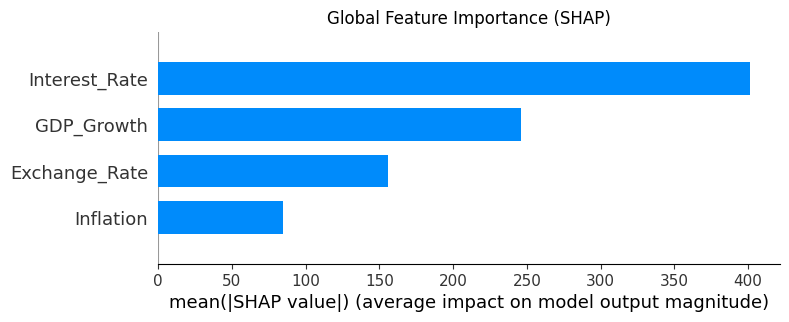

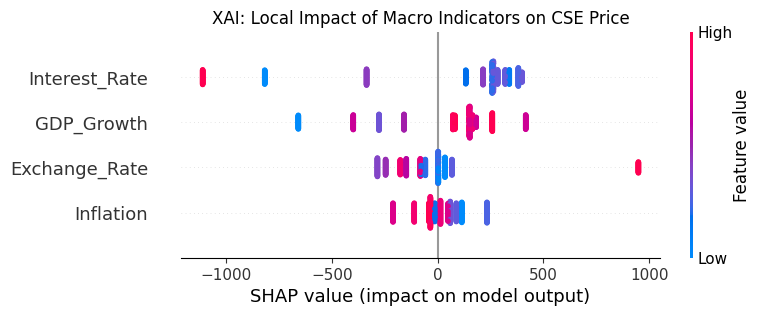

Training complete. Model saved to ../models/cse_model.pkl


In [16]:
# Model Training Notebook - 4 Indicator Version
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import pickle
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load Data
# The processed data now includes: Close, Inflation, GDP_Growth, Interest_Rate, Exchange_Rate
# Check if running from notebooks directory or root
if os.path.exists('../data/processed/processed_data.csv'):
    df = pd.read_csv('../data/processed/processed_data.csv')
else:
    df = pd.read_csv('data/processed/processed_data.csv')

# Define Features (X) and Target (y)
# We use all 4 macroeconomic indicators as our feature set
X = df[['Inflation', 'GDP_Growth', 'Interest_Rate', 'Exchange_Rate']]
y = df['Close']

# 2. Train/Test Split
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Selection: LightGBM (Requirement 2)
# Justification: LightGBM is highly efficient for tabular data. 
# It uses Gradient-based One-Side Sampling (GOSS) to handle large data 
# and Leaf-wise growth to minimize loss more effectively than level-wise trees.
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    min_data_in_leaf=1,  # Forces trees to grow even with small data
    num_leaves=10,       # Keep it small to avoid overfitting
    random_state=42
)

print("Training LightGBM model...")
model.fit(X_train, y_train)

# 4. Evaluation (Requirement 3)
preds = model.predict(X_test)

# Evaluation Metrics Calculation
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"\n--- Evaluation Metrics ---")
print(f"RMSE: {rmse:.2f} (Average prediction error in index points)")
print(f"MAE:  {mae:.2f} (Mean Absolute Error)")
print(f"R2 Score: {r2:.2f} (Percentage of market variance explained)")

# 5. Explainability with SHAP (Requirement 4)
# This is crucial for interpreting how the LKR stability and Interest rates 
# are impacting the Colombo Stock Exchange.
print("\nGenerating SHAP explanations...")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("XAI: Local Impact of Macro Indicators on CSE Price")
plt.show()

# 6. Save Model
# Robust path handling for models directory
if os.path.exists('../models'):
    model_path = '../models/cse_model.pkl'
else:
    os.makedirs('models', exist_ok=True)
    model_path = 'models/cse_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Training complete. Model saved to {model_path}")